# Tournament results analysis

Notebook for inspecting outputs produced by the tournament pipeline. It expects CSV/JSONL files created by:

1. `scripts/run_tournament.py`
2. `scripts/analyze_tournament.py`
3. optionally `scripts/score_blunders.py`

Change `RESULTS_DIR` to analyze another run.

In [11]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))
RESULTS_DIR = PROJECT_ROOT / "results" / "e2e_smoke_runner"
RESULTS_DIR

WindowsPath('<LOCAL_PROJECT>/results/e2e_smoke_runner')

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
plt.style.use("seaborn-v0_8-whitegrid")

In [13]:
def read_csv_if_exists(name: str) -> pd.DataFrame:
    path = RESULTS_DIR / name
    if not path.exists():
        print(f"Missing: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)

games = read_csv_if_exists("games.csv")
standings = read_csv_if_exists("standings.csv")
pair_summary = read_csv_if_exists("pair_summary.csv")
agent_summary = read_csv_if_exists("agent_summary.csv")
matchup_summary = read_csv_if_exists("matchup_summary.csv")
llm_summary = read_csv_if_exists("llm_summary.csv")
blunders = read_csv_if_exists("blunders.csv")
blunder_summary = read_csv_if_exists("blunder_summary.csv")

print("games", len(games))
print("moves scored for blunders", len(blunders))

Missing: <LOCAL_PROJECT>\results\e2e_smoke_runner\llm_summary.csv
games 15
moves scored for blunders 60


## Standings

In [14]:
if not agent_summary.empty:
    cols = [
        "rank", "agent", "kind", "games", "wins", "losses", "draws",
        "win_rate", "draw_rate", "avg_moves_per_game", "avg_decision_seconds",
        "tree_growth", "avg_legal_moves",
    ]
    existing = [col for col in cols if col in agent_summary.columns]
    display(
        agent_summary[existing]
        .sort_values("rank")
        .style.format({
            "win_rate": "{:.1%}",
            "draw_rate": "{:.1%}",
            "avg_moves_per_game": "{:.2f}",
            "avg_decision_seconds": "{:.4f}",
            "avg_legal_moves": "{:.2f}",
        })
    )

,rank,agent,kind,games,wins,losses,draws,win_rate,draw_rate,avg_moves_per_game,avg_decision_seconds,tree_growth,avg_legal_moves
0,1,uct-m0,mcts,5,5,0,0,100.0%,0.0%,38.80,0.4701,52452,12.39
1,2,pmbp-2.5-m0,mcts,5,3,2,0,60.0%,0.0%,34.40,0.4895,46037,12.86
2,3,fpu-1.0-m0,mcts,5,3,2,0,60.0%,0.0%,39.20,0.5384,141386,12.18
3,4,minimax-d2,builtin,5,2,3,0,40.0%,0.0%,34.00,0.0484,0,12.73
4,5,lgr-m0,mcts,5,2,3,0,40.0%,0.0%,35.60,0.4431,44181,12.17
5,6,random,builtin,5,0,5,0,0.0%,0.0%,22.80,0.0000,0,15.54


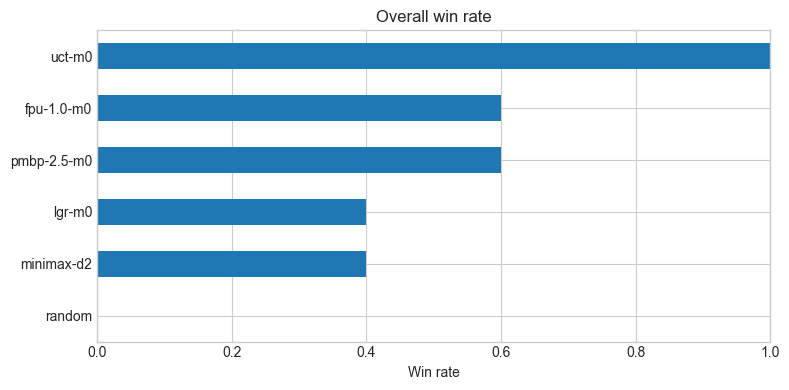

In [15]:
if not agent_summary.empty:
    plot_df = agent_summary.sort_values("win_rate", ascending=True)
    ax = plot_df.plot.barh(x="agent", y="win_rate", legend=False, figsize=(8, max(4, len(plot_df) * 0.45)))
    ax.set_xlim(0, 1)
    ax.set_xlabel("Win rate")
    ax.set_ylabel("")
    ax.set_title("Overall win rate")
    plt.tight_layout()
    plt.show()

## Matchups and Side Balance

In [16]:
if not matchup_summary.empty:
    cols = [
        "pair_id", "left", "right", "games", "left_wins", "right_wins", "draws",
        "left_win_rate", "right_win_rate", "draw_rate", "avg_moves",
        "left_avg_decision_seconds", "right_avg_decision_seconds",
    ]
    existing = [col for col in cols if col in matchup_summary.columns]
    display(
        matchup_summary[existing]
        .sort_values("pair_id")
        .style.format({
            "left_win_rate": "{:.1%}",
            "right_win_rate": "{:.1%}",
            "draw_rate": "{:.1%}",
            "avg_moves": "{:.2f}",
            "left_avg_decision_seconds": "{:.4f}",
            "right_avg_decision_seconds": "{:.4f}",
        })
    )

,pair_id,left,right,games,left_wins,right_wins,draws,left_win_rate,right_win_rate,draw_rate,avg_moves,left_avg_decision_seconds,right_avg_decision_seconds
0,fpu-1.0-m0_vs_lgr-m0,fpu-1.0-m0,lgr-m0,1,1,0,0,100.0%,0.0%,0.0%,46.00,0.4992,0.3788
1,fpu-1.0-m0_vs_pmbp-2.5-m0,fpu-1.0-m0,pmbp-2.5-m0,1,0,1,0,0.0%,100.0%,0.0%,38.00,0.5878,0.4478
2,minimax-d2_vs_fpu-1.0-m0,minimax-d2,fpu-1.0-m0,1,0,1,0,0.0%,100.0%,0.0%,44.00,0.0404,0.5209
3,minimax-d2_vs_lgr-m0,minimax-d2,lgr-m0,1,0,1,0,0.0%,100.0%,0.0%,36.00,0.0498,0.4387
4,minimax-d2_vs_pmbp-2.5-m0,minimax-d2,pmbp-2.5-m0,1,1,0,0,100.0%,0.0%,0.0%,28.00,0.0424,0.4237
5,minimax-d2_vs_uct-m0,minimax-d2,uct-m0,1,0,1,0,0.0%,100.0%,0.0%,38.00,0.0436,0.5395
6,pmbp-2.5-m0_vs_lgr-m0,pmbp-2.5-m0,lgr-m0,1,1,0,0,100.0%,0.0%,0.0%,42.00,0.6568,0.5168
7,random_vs_fpu-1.0-m0,random,fpu-1.0-m0,1,0,1,0,0.0%,100.0%,0.0%,22.00,0.0000,0.6272
8,random_vs_lgr-m0,random,lgr-m0,1,0,1,0,0.0%,100.0%,0.0%,14.00,0.0000,0.4652
9,random_vs_minimax-d2,random,minimax-d2,1,0,1,0,0.0%,100.0%,0.0%,24.00,0.0000,0.0758


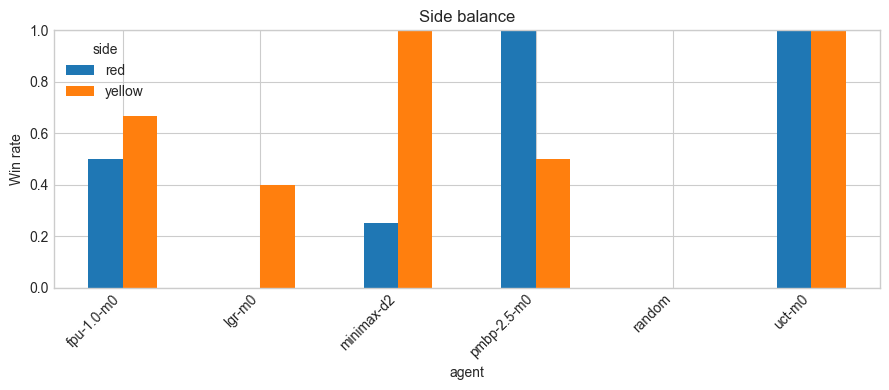

In [17]:
if not agent_summary.empty and {"win_rate_as_red", "win_rate_as_yellow"}.issubset(agent_summary.columns):
    side_df = agent_summary.melt(
        id_vars=["agent"],
        value_vars=["win_rate_as_red", "win_rate_as_yellow"],
        var_name="side",
        value_name="side_win_rate",
    )
    side_df["side"] = side_df["side"].map({"win_rate_as_red": "red", "win_rate_as_yellow": "yellow"})
    pivot = side_df.pivot(index="agent", columns="side", values="side_win_rate")
    ax = pivot.plot.bar(figsize=(9, 4))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Win rate")
    ax.set_title("Side balance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Decision Time

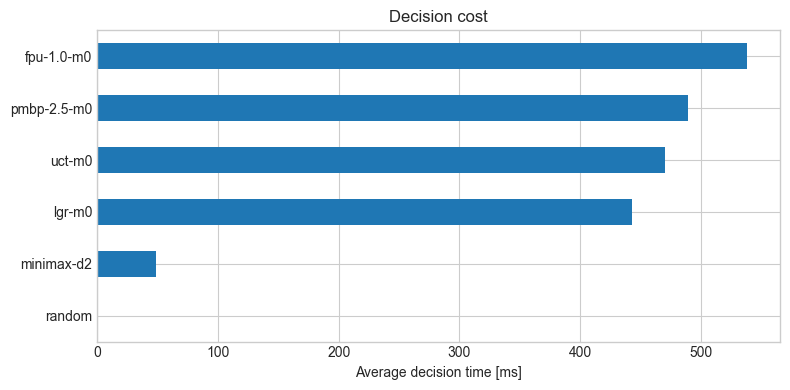

In [18]:
if not agent_summary.empty:
    time_df = agent_summary.copy()
    time_df["avg_decision_ms"] = time_df["avg_decision_seconds"] * 1000
    ax = time_df.sort_values("avg_decision_ms").plot.barh(
        x="agent",
        y="avg_decision_ms",
        legend=False,
        figsize=(8, max(4, len(time_df) * 0.45)),
    )
    ax.set_xlabel("Average decision time [ms]")
    ax.set_ylabel("")
    ax.set_title("Decision cost")
    plt.tight_layout()
    plt.show()

## Blunder Rate

In [19]:
if not blunder_summary.empty:
    cols = [
        "agent", "scored_moves", "moves_with_known_value", "blunders", "blunder_rate",
        "avg_regret", "avg_chosen_value", "avg_best_value",
    ]
    existing = [col for col in cols if col in blunder_summary.columns]
    display(
        blunder_summary[existing]
        .sort_values("blunder_rate")
        .style.format({
            "blunder_rate": "{:.1%}",
            "avg_regret": "{:.3f}",
            "avg_chosen_value": "{:.3f}",
            "avg_best_value": "{:.3f}",
        })
    )
else:
    print("No blunder_summary.csv found. Run scripts/score_blunders.py first.")

,agent,scored_moves,moves_with_known_value,blunders,blunder_rate,avg_regret,avg_chosen_value,avg_best_value
0,uct-m0,15,15,0,0.0%,0.103,0.615,0.718
1,minimax-d2,12,12,0,0.0%,0.113,0.479,0.592
2,fpu-1.0-m0,3,3,0,0.0%,0.070,0.540,0.610
3,random,30,30,2,6.7%,0.130,0.426,0.557


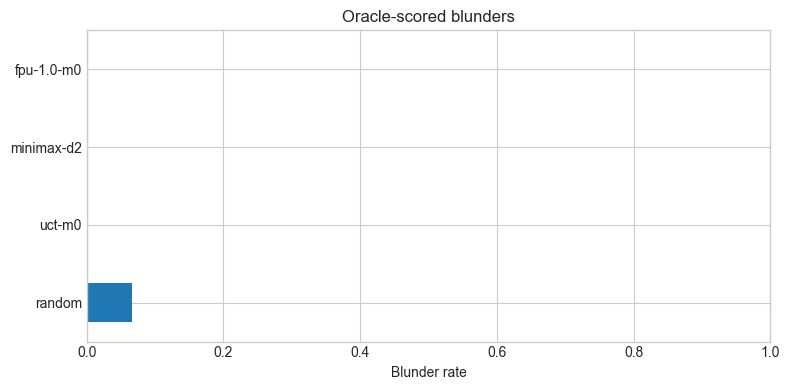

In [20]:
if not blunder_summary.empty:
    plot_df = blunder_summary.sort_values("blunder_rate", ascending=False)
    ax = plot_df.plot.barh(x="agent", y="blunder_rate", legend=False, figsize=(8, max(4, len(plot_df) * 0.45)))
    ax.set_xlim(0, 1)
    ax.set_xlabel("Blunder rate")
    ax.set_ylabel("")
    ax.set_title("Oracle-scored blunders")
    plt.tight_layout()
    plt.show()

## LLM Reliability

In [21]:
if not llm_summary.empty:
    display(
        llm_summary.sort_values("llm_invalid_response_rate", ascending=False)
        .style.format({
            "llm_invalid_response_rate": "{:.1%}",
            "llm_fallback_rate": "{:.1%}",
            "avg_decision_seconds": "{:.4f}",
            "win_rate": "{:.1%}",
        })
    )
else:
    print("No LLM rows in this run.")

No LLM rows in this run.


## Raw Game Samples

In [22]:
if not games.empty:
    cols = [
        "game_id", "pair_id", "seed", "red_agent", "yellow_agent", "winner_agent",
        "red_lines", "yellow_lines", "moves", "red_avg_decision_seconds", "yellow_avg_decision_seconds",
    ]
    existing = [col for col in cols if col in games.columns]
    display(games[existing].head(20))

,game_id,pair_id,seed,red_agent,yellow_agent,winner_agent,red_lines,yellow_lines,moves,red_avg_decision_seconds,yellow_avg_decision_seconds
0,random_vs_minimax-d2_g0000,random_vs_minimax-d2,100,random,minimax-d2,minimax-d2,1,0,24,0.000008,0.075818
1,random_vs_uct-m0_g0000,random_vs_uct-m0,200,random,uct-m0,uct-m0,1,0,30,0.000007,0.455612
2,random_vs_fpu-1.0-m0_g0000,random_vs_fpu-1.0-m0,300,random,fpu-1.0-m0,fpu-1.0-m0,1,0,22,0.000006,0.627199
3,random_vs_pmbp-2.5-m0_g0000,random_vs_pmbp-2.5-m0,400,random,pmbp-2.5-m0,pmbp-2.5-m0,1,0,24,0.000005,0.459087
4,random_vs_lgr-m0_g0000,random_vs_lgr-m0,500,random,lgr-m0,lgr-m0,1,0,14,0.000016,0.465250
5,minimax-d2_vs_uct-m0_g0000,minimax-d2_vs_uct-m0,100200,minimax-d2,uct-m0,uct-m0,1,0,38,0.043596,0.539467
6,minimax-d2_vs_fpu-1.0-m0_g0000,minimax-d2_vs_fpu-1.0-m0,100300,minimax-d2,fpu-1.0-m0,fpu-1.0-m0,2,1,44,0.040418,0.520938
7,minimax-d2_vs_pmbp-2.5-m0_g0000,minimax-d2_vs_pmbp-2.5-m0,100400,minimax-d2,pmbp-2.5-m0,minimax-d2,0,1,28,0.042369,0.423749
8,minimax-d2_vs_lgr-m0_g0000,minimax-d2_vs_lgr-m0,100500,minimax-d2,lgr-m0,lgr-m0,1,0,36,0.049838,0.438724
9,uct-m0_vs_fpu-1.0-m0_g0000,uct-m0_vs_fpu-1.0-m0,200300,uct-m0,fpu-1.0-m0,uct-m0,2,3,46,0.449695,0.511187
